# Numpy and Xarray

Most neuroscience data ends up as a multidimensional array at some point: a recording with samples and channels, an image stack with pixels and time, or a tensor of trials, conditions, and time points. This homework session introduces the two array libraries:

- **NumPy** provides the n-dimensional array (`ndarray`) and the vectorised operations that work on it.
- **Xarray** builds on top of NumPy by attaching *names*, *coordinates*, and *metadata* to each axis, so that you can refer to dimensions and indices by meaning rather than by position.

## Setup

### Import Libraries

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

## NumPy Arrays

### Background

Numpy can be used to store data of the same type together in array. Compared to plain Python lists, arrays are more memory-efficient and faster for numerical work. An array has a fixed `shape` (the size of each dimension) and a `dtype` (the type of element stored), and supports slicing and arithmetic along chosen axes of your array. In this section you will learn different ways of creating arrays, how to access specific columns, rows, or elements with slicing, and how to perform mathematical operations on the data in your array.

### Exercises

| Code | Description |
| :-- | :-- |
| `np.linspace(0, 1, 10)` | 10 evenly spaced values between 0 and 1 (inclusive). |
| `np.random.uniform(0, 1, size=10)` | 10 random numbers drawn uniformly between 0 and 1. |
| `np.zeros(8)` | Create a 1-D array of length 8 filled with zeros. |
| `np.zeros((2, 3))` | Create a 2x3 array filled with zeros. |
| `np.ones(n)` | Create an array of length `n` filled with ones. |
| `a.shape` | Inspect the array shape (the size of each dimension). |
| `a[0]`, `a[:, 1]` | Select a row, or select a column with `:` along one axis. |
| `a.mean(axis=1)`, `a.mean(axis=0)`, `a.mean()` | Average along a chosen axis, or over all elements. |

**Example**: Create an array containing 10 evenly spaced points from 0 to 1.

In [2]:
np.linspace(0, 1, 10)

array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ])

**Exercise**: Create an array containing 100 evenly spaced points from 0 to 2.

In [3]:
np.linspace(0, 2, 100)

array([0.        , 0.02020202, 0.04040404, 0.06060606, 0.08080808,
       0.1010101 , 0.12121212, 0.14141414, 0.16161616, 0.18181818,
       0.2020202 , 0.22222222, 0.24242424, 0.26262626, 0.28282828,
       0.3030303 , 0.32323232, 0.34343434, 0.36363636, 0.38383838,
       0.4040404 , 0.42424242, 0.44444444, 0.46464646, 0.48484848,
       0.50505051, 0.52525253, 0.54545455, 0.56565657, 0.58585859,
       0.60606061, 0.62626263, 0.64646465, 0.66666667, 0.68686869,
       0.70707071, 0.72727273, 0.74747475, 0.76767677, 0.78787879,
       0.80808081, 0.82828283, 0.84848485, 0.86868687, 0.88888889,
       0.90909091, 0.92929293, 0.94949495, 0.96969697, 0.98989899,
       1.01010101, 1.03030303, 1.05050505, 1.07070707, 1.09090909,
       1.11111111, 1.13131313, 1.15151515, 1.17171717, 1.19191919,
       1.21212121, 1.23232323, 1.25252525, 1.27272727, 1.29292929,
       1.31313131, 1.33333333, 1.35353535, 1.37373737, 1.39393939,
       1.41414141, 1.43434343, 1.45454545, 1.47474747, 1.49494

**Exercise**: Create an array containing 11 evenly spaced points from 0 to 10.

In [4]:
np.linspace(0, 10, 11)

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

**Exercise**: Create an array containing 10 random numbers between 0 and 1.

In [5]:
np.random.uniform(0, 1, size=10)

array([0.27328536, 0.83400527, 0.50129975, 0.13076042, 0.76740523,
       0.67226989, 0.90822462, 0.98072781, 0.10825356, 0.29554128])

**Exercise**: Create an array containing 10 random numbers between -5 and 5.

In [6]:
np.random.uniform(-5, 5, size=10)

array([ 3.87181751,  3.10593325,  4.28334389,  0.93912668,  3.78716981,
        2.16254772, -4.69524007,  4.46617731, -0.09614188, -1.69549173])

**Exercise**: Create an array of length `8` containing zeros.

In [7]:
np.zeros(8)

array([0., 0., 0., 0., 0., 0., 0., 0.])

**Exercise**: Create a 2D array of dimensions `(2, 3)` containing zeros.

In [8]:
np.zeros((2,3))

array([[0., 0., 0.],
       [0., 0., 0.]])

**Exercise**: Create a 2D array of dimensions `(4, 10)` containing zeros and assign it to a variable named `data`.

In [9]:
data = np.zeros((4,10))
data.shape

(4, 10)

Run the cell below to create a 2D array named `data` with dimensions `(4,10)` containing numbers between 0's on the first row, 1's on the second row, 2's on the third row, and 3's on the third row.

In [10]:
data = np.zeros((4,10))
data[1, :] += np.ones(data.shape[1])
data[2, :] += 2*np.ones(data.shape[1])
data[3, :] += 3*np.ones(data.shape[1])
data

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [2., 2., 2., 2., 2., 2., 2., 2., 2., 2.],
       [3., 3., 3., 3., 3., 3., 3., 3., 3., 3.]])

**Exercise**: Compute the mean of `data` across rows (axis 1). The result should contain 4 numbers.

In [11]:
data.mean(axis=1)

array([0., 1., 2., 3.])

**Exercise**: Compute the mean of `data` across columns (axis 0). The result should contain 10 numbers.

In [12]:
data.mean(axis=0)

array([1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5])

**Exercise**: Compute the mean of all elements (no axis specification) in `data`. The result should be a single number.

In [13]:
data.mean()

np.float64(1.5)

**Exercise**: Select the first row in `data`.

In [14]:
data[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

**Exercise**: Select the second row in `data`.

In [15]:
data[1]

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

**Exercise**: Select the second *column* in `data`.

In [16]:
data[:, 1]

array([0., 1., 2., 3.])

## Intro to Working with Xarray

### Background

NumPy arrays are powerful but minimal: they store numerical data without any built-in information about what the axes represent. In scientific datasets, however, each axis usually corresponds to meaningful quantities such as space, time, wavelength, or experimental condition. When working with multidimensional data, it is often useful to label these dimensions explicitly.

**[Xarray](https://docs.xarray.dev/en/stable/user-guide/index.html)** extends NumPy by adding labels and metadata to multidimensional arrays. Each array can have named dimensions, coordinate values, and descriptive metadata attached to it. This makes many operations clearer and safer, since calculations can reference dimensions by name rather than by numeric index.

### Exercises

In this section you will create `DataArray`s from NumPy arrays, attach coordinates and metadata, and select data by name and by label.

| Code | Description |
| :-- | :-- |
| `xr.DataArray(data=a, dims=['channel', 'time'])` | Wrap a NumPy array `a` and name its axes. |
| `xr.DataArray(data=a, dims=['channel', 'time'], coords={'time': t, 'channel': ch}, name='eeg')` | Attach coordinate values and a variable name. |
| `da['time']` | Access the `time` coordinate. |
| `da.sel(channel='Cz')` | Select the data for a single named channel. |
| `da.sel(time=slice(0.5, 1.0))` | Select all samples whose `time` coordinate is between 0.5 and 1.0. |
| `da.sel(channel=['Cz', 'Fz'])` | Select two named channels at once. |
| `da.mean(dim='time')` | Reduce along a named dimension. |
| `da.attrs = {'units': 'uV'}` | Attach metadata describing the array. |
| `da.plot()` | Quick plot that uses dimension names and coordinates as axis labels. |

The exercises in this section introduce the core concepts of XArray: treating a DataArray like a NumPy array, labeling dimensions, attaching coordinates, and adding metadata to describe the data.

#### `xr.DataArray()` as a Numpy-Like Array

At its core, an XArray DataArray wraps a NumPy array. Most numerical operations that work on NumPy arrays also work on DataArray objects, including slicing, aggregation, and arithmetic. This means that existing NumPy-style code often requires very little modification to work with labeled arrays.

**Example**: Create a three-dimensional `DataArray` from a Numpy array:

In [17]:
da = xr.DataArray(
    data=np.random.random(size=(10, 20, 30))
)
da

<xarray.DataArray (dim_0: 10, dim_1: 20, dim_2: 30)> Size: 48kB
array([[[0.23788368, 0.23605966, 0.80228579, ..., 0.68898002,
         0.07853281, 0.19380517],
        [0.14130516, 0.65707645, 0.23141506, ..., 0.52924041,
         0.31846831, 0.01915002],
        [0.69098142, 0.55415371, 0.03406188, ..., 0.30671041,
         0.05645876, 0.76984313],
        ...,
        [0.68203746, 0.9773155 , 0.6563993 , ..., 0.39435901,
         0.15916685, 0.54664456],
        [0.30839868, 0.07524659, 0.76109123, ..., 0.6643156 ,
         0.2775079 , 0.81241316],
        [0.88375706, 0.28650796, 0.71002523, ..., 0.27631181,
         0.4693783 , 0.64246215]],

       [[0.86237064, 0.20470568, 0.97579391, ..., 0.89611761,
         0.41012618, 0.65192975],
        [0.45620437, 0.46711698, 0.19830768, ..., 0.69645675,
         0.37366346, 0.66273108],
        [0.01584745, 0.83562461, 0.28550591, ..., 0.45160754,
         0.44648287, 0.96858596],
...
        [0.29986454, 0.34874492, 0.03265512, ..., 0.22039787,
         0.65331242, 0.08704563],
        [0.49125804, 0.05044699, 0.73502377, ..., 0.64627574,
         0.9575063 , 0.96525506],
        [0.88144935, 0.94536675, 0.08156956, ..., 0.60773129,
         0.2189179 , 0.68175517]],

       [[0.67127099, 0.86806711, 0.91718242, ..., 0.62449025,
         0.44841741, 0.72151004],
        [0.32736636, 0.76220637, 0.39107574, ..., 0.85081758,
         0.10898503, 0.90099856],
        [0.30688208, 0.10380307, 0.04291056, ..., 0.95853621,
         0.36764205, 0.2602685 ],
        ...,
        [0.75813385, 0.55370523, 0.52272732, ..., 0.71842   ,
         0.90350042, 0.35238473],
        [0.70299704, 0.98219572, 0.07206044, ..., 0.7188582 ,
         0.40063133, 0.38158656],
        [0.45821474, 0.25588665, 0.21670261, ..., 0.01642515,
         0.28057241, 0.87116493]]], shape=(10, 20, 30))
Dimensions without coordinates: dim_0, dim_1, dim_2

**Exercise**: Select the first 5 rows of `da`, using the slicing syntax `x[:10, :, :]`

In [18]:
da[:5, :, :]

<xarray.DataArray (dim_0: 5, dim_1: 20, dim_2: 30)> Size: 24kB
array([[[0.23788368, 0.23605966, 0.80228579, ..., 0.68898002,
         0.07853281, 0.19380517],
        [0.14130516, 0.65707645, 0.23141506, ..., 0.52924041,
         0.31846831, 0.01915002],
        [0.69098142, 0.55415371, 0.03406188, ..., 0.30671041,
         0.05645876, 0.76984313],
        ...,
        [0.68203746, 0.9773155 , 0.6563993 , ..., 0.39435901,
         0.15916685, 0.54664456],
        [0.30839868, 0.07524659, 0.76109123, ..., 0.6643156 ,
         0.2775079 , 0.81241316],
        [0.88375706, 0.28650796, 0.71002523, ..., 0.27631181,
         0.4693783 , 0.64246215]],

       [[0.86237064, 0.20470568, 0.97579391, ..., 0.89611761,
         0.41012618, 0.65192975],
        [0.45620437, 0.46711698, 0.19830768, ..., 0.69645675,
         0.37366346, 0.66273108],
        [0.01584745, 0.83562461, 0.28550591, ..., 0.45160754,
         0.44648287, 0.96858596],
...
        [0.73403717, 0.16371518, 0.44273412, ..., 0.12866676,
         0.01187013, 0.69307243],
        [0.05543008, 0.90932005, 0.15656139, ..., 0.17250121,
         0.86126565, 0.45913999],
        [0.84709603, 0.17624627, 0.92321201, ..., 0.56936885,
         0.84405379, 0.05026134]],

       [[0.41632924, 0.76755178, 0.05502857, ..., 0.8447503 ,
         0.52860366, 0.30134156],
        [0.18535428, 0.08939203, 0.20576092, ..., 0.68661574,
         0.65123844, 0.37999637],
        [0.47273012, 0.28950914, 0.08807864, ..., 0.30355157,
         0.98412542, 0.09479784],
        ...,
        [0.02761774, 0.37307151, 0.27824831, ..., 0.7846741 ,
         0.84080575, 0.3063337 ],
        [0.77536553, 0.5886622 , 0.11761207, ..., 0.39168492,
         0.62287169, 0.54901424],
        [0.05718255, 0.86226232, 0.34044172, ..., 0.95999234,
         0.06403369, 0.78082937]]], shape=(5, 20, 30))
Dimensions without coordinates: dim_0, dim_1, dim_2

**Exercise**: Compute the mean, using either `DataArray.mean()` or `np.mean()`

In [19]:
da.mean()

<xarray.DataArray ()> Size: 8B
array(0.49888593)

In [20]:
np.mean(da)

<xarray.DataArray ()> Size: 8B
array(0.49888593)

**Exercise**: Compute the mean over the third axis, using `da.mean(axis=2)`

In [21]:
da.mean(axis=2)

<xarray.DataArray (dim_0: 10, dim_1: 20)> Size: 2kB
array([[0.45831554, 0.46406373, 0.53232359, 0.49771978, 0.44566037,
        0.50448159, 0.48853361, 0.50987568, 0.49653065, 0.51773812,
        0.39753509, 0.46077325, 0.53329706, 0.53343356, 0.53752155,
        0.49433733, 0.44620991, 0.53085686, 0.53270157, 0.53595397],
       [0.55542388, 0.43862237, 0.46039014, 0.45721817, 0.52277391,
        0.41999437, 0.48053987, 0.51601608, 0.45034168, 0.52554843,
        0.52218263, 0.56336486, 0.51968687, 0.49309449, 0.54810805,
        0.58154989, 0.53075114, 0.61348216, 0.48206282, 0.46329848],
       [0.46795029, 0.53460594, 0.43819607, 0.45100184, 0.52357612,
        0.54392174, 0.53868345, 0.44802674, 0.50103975, 0.62688166,
        0.49997196, 0.54686243, 0.52804113, 0.5320996 , 0.51791631,
        0.5935157 , 0.47121173, 0.54015539, 0.56211941, 0.53110262],
       [0.4912366 , 0.50542106, 0.5378713 , 0.44256479, 0.50770139,
        0.5537548 , 0.50895707, 0.47815145, 0.4128692 , 0.50878851,
        0.43200351, 0.46555934, 0.4844372 , 0.49308003, 0.47959358,
        0.4014133 , 0.49887378, 0.44380584, 0.47941065, 0.53451228],
       [0.53987282, 0.46127482, 0.39154115, 0.52034628, 0.53130019,
        0.54381132, 0.51000019, 0.52317078, 0.53005217, 0.47626483,
        0.47121473, 0.51380763, 0.48013196, 0.51457249, 0.49182492,
        0.42967072, 0.45603868, 0.5409889 , 0.52565994, 0.47875087],
       [0.40973751, 0.51329554, 0.42193709, 0.51544671, 0.47719184,
        0.49345285, 0.52151936, 0.48918067, 0.6336813 , 0.54459769,
        0.56758039, 0.51065737, 0.52706015, 0.48629554, 0.47173396,
        0.50666616, 0.43959324, 0.5801705 , 0.39950776, 0.57409312],
       [0.50677234, 0.46728804, 0.54739023, 0.54787946, 0.51960132,
        0.49601006, 0.49331386, 0.53473   , 0.53013125, 0.39517383,
        0.42428462, 0.43808804, 0.52889101, 0.54083048, 0.46409929,
        0.50971512, 0.50361452, 0.56749069, 0.43462327, 0.49856513],
       [0.50102469, 0.39826899, 0.50340268, 0.51318157, 0.5516999 ,
        0.49486742, 0.53018322, 0.5135183 , 0.50307893, 0.55564936,
        0.49265567, 0.51021986, 0.48953299, 0.45321537, 0.46356363,
        0.51064433, 0.37784283, 0.47194547, 0.48313629, 0.52597294],
       [0.47950414, 0.45713798, 0.51855551, 0.53141971, 0.48656579,
        0.52377128, 0.45787945, 0.46202314, 0.49655381, 0.46937189,
        0.48270506, 0.45307671, 0.51967235, 0.5047249 , 0.52079534,
        0.43187062, 0.44375656, 0.51849577, 0.51088805, 0.59797819],
       [0.5788061 , 0.54676593, 0.49382598, 0.48471131, 0.57119947,
        0.48781789, 0.49725994, 0.52355193, 0.4660449 , 0.40061818,
        0.49616026, 0.44515537, 0.567306  , 0.46929089, 0.43409951,
        0.47303689, 0.52730106, 0.46475815, 0.5867906 , 0.47094966]])
Dimensions without coordinates: dim_0, dim_1

#### Labeling the Data and the Dimensions: `name=` and `dims=`

One of XArray’s most useful features is the ability to name dimensions explicitly. Instead of referring to axes by position—such as “axis 0” or “axis 2”—operations can refer to dimensions using meaningful labels like "x", "y", or "time".

Once dimensions are named, many operations become easier to read and harder to misuse. For example, computing the mean across time can be expressed as mean(dim="time"), which clearly communicates the intent of the calculation.

**Exercise**: Make a new `da` 3-dimensional array variable using `xr.DataArray()`, this time additionally setting `name="image"` and `dims=['x', 'y', 'time']`

In [22]:
da = xr.DataArray(
    data=np.random.random(size=(10, 20, 30)),
    name='image',
    dims=['x', 'y', 'time']
)
da

<xarray.DataArray 'image' (x: 10, y: 20, time: 30)> Size: 48kB
array([[[0.21907537, 0.20502939, 0.41814277, ..., 0.76248316,
         0.56642316, 0.28743011],
        [0.60516054, 0.02921786, 0.45099535, ..., 0.5179664 ,
         0.70372603, 0.1148873 ],
        [0.56572838, 0.22272419, 0.51647826, ..., 0.59090934,
         0.33127544, 0.46190144],
        ...,
        [0.37689109, 0.09457398, 0.55114565, ..., 0.6546139 ,
         0.85841306, 0.88211453],
        [0.82273528, 0.19455883, 0.46367668, ..., 0.34374775,
         0.25156959, 0.02818155],
        [0.69305668, 0.60569189, 0.88344973, ..., 0.31025998,
         0.01051023, 0.50323947]],

       [[0.42127843, 0.40629273, 0.41555451, ..., 0.77711814,
         0.54755719, 0.88209125],
        [0.93764808, 0.70178074, 0.33355596, ..., 0.40964367,
         0.02470199, 0.31973489],
        [0.4757714 , 0.38051748, 0.05047711, ..., 0.7750013 ,
         0.87602934, 0.84114046],
...
        [0.67204049, 0.96845349, 0.80800288, ..., 0.45649738,
         0.48744592, 0.46446953],
        [0.340463  , 0.35267054, 0.40884896, ..., 0.9179869 ,
         0.9880542 , 0.4809745 ],
        [0.05183772, 0.63606649, 0.32939687, ..., 0.05622369,
         0.96154879, 0.21826723]],

       [[0.6096255 , 0.71506045, 0.51181931, ..., 0.69103162,
         0.64328308, 0.32531749],
        [0.85676502, 0.71322308, 0.7181776 , ..., 0.92000372,
         0.48436441, 0.36410102],
        [0.21810124, 0.41572483, 0.86673842, ..., 0.10276199,
         0.44600278, 0.36731628],
        ...,
        [0.49311358, 0.88432823, 0.81573679, ..., 0.11768327,
         0.84469017, 0.94140818],
        [0.54686906, 0.77835156, 0.28880879, ..., 0.03832547,
         0.13836515, 0.18130482],
        [0.35428962, 0.29865035, 0.69541319, ..., 0.06601711,
         0.36919941, 0.97567985]]], shape=(10, 20, 30))
Dimensions without coordinates: x, y, time

**Exercise**: Select the fourth time sample using `da.sel(time=4)`

In [23]:
da.sel(time=4)

<xarray.DataArray 'image' (x: 10, y: 20)> Size: 2kB
array([[0.70118942, 0.75631421, 0.20357631, 0.83168994, 0.47161744,
        0.37028442, 0.50626923, 0.07905263, 0.61540043, 0.49640693,
        0.00186004, 0.66789983, 0.82530489, 0.12822235, 0.08374109,
        0.83365259, 0.92302338, 0.58180225, 0.85508619, 0.0114542 ],
       [0.77390028, 0.90442935, 0.19525926, 0.42161297, 0.02764433,
        0.80940873, 0.11840977, 0.04383632, 0.80854342, 0.96794306,
        0.03001484, 0.278606  , 0.18060943, 0.27021601, 0.72100895,
        0.71224755, 0.69943574, 0.02103048, 0.0360004 , 0.85546662],
       [0.07561112, 0.83442842, 0.74221683, 0.93067917, 0.91892677,
        0.0350837 , 0.77249154, 0.41669346, 0.61456573, 0.02300186,
        0.25835077, 0.77744794, 0.65653884, 0.80186124, 0.0988786 ,
        0.25755544, 0.13169896, 0.39341778, 0.10987423, 0.1234385 ],
       [0.0230825 , 0.37216428, 0.85179074, 0.96266159, 0.53685176,
        0.40263499, 0.64565513, 0.72798478, 0.77089855, 0.1569499 ,
        0.02739518, 0.63231731, 0.94043807, 0.18457433, 0.56764689,
        0.4773664 , 0.87717119, 0.18989927, 0.29890257, 0.76575315],
       [0.94780689, 0.15354663, 0.40025305, 0.76367446, 0.38292258,
        0.26503248, 0.44657636, 0.30522437, 0.74746519, 0.60653873,
        0.32712804, 0.27745879, 0.50709061, 0.03499694, 0.2442496 ,
        0.75419301, 0.25202798, 0.7770708 , 0.23674676, 0.59981368],
       [0.52935748, 0.64405069, 0.38095461, 0.88130183, 0.12670423,
        0.09610235, 0.12412658, 0.79012507, 0.94701158, 0.39019222,
        0.75873184, 0.53924159, 0.67996829, 0.24437098, 0.35403637,
        0.60100353, 0.89212715, 0.07350739, 0.65523654, 0.99261692],
       [0.94626262, 0.51435156, 0.59750137, 0.20876951, 0.50249091,
        0.90102642, 0.90077403, 0.48196901, 0.21252669, 0.0106714 ,
        0.94707882, 0.65968449, 0.64124678, 0.08816975, 0.73949026,
        0.49207247, 0.84524281, 0.75229387, 0.44354298, 0.49931544],
       [0.34739362, 0.17807199, 0.97603161, 0.9117008 , 0.27427713,
        0.52605328, 0.3262784 , 0.59727904, 0.89123895, 0.19841049,
        0.39312206, 0.43026225, 0.34841549, 0.08440455, 0.2576354 ,
        0.61471762, 0.46991844, 0.95995103, 0.14937359, 0.18403329],
       [0.24661919, 0.68740983, 0.05692259, 0.77608066, 0.87041119,
        0.91896552, 0.38242105, 0.24754023, 0.22556381, 0.47014899,
        0.45554216, 0.51327286, 0.23676728, 0.77553143, 0.15760988,
        0.25177201, 0.56993673, 0.59108533, 0.12310597, 0.61211817],
       [0.57395267, 0.51525562, 0.93177374, 0.84532886, 0.62086003,
        0.01324768, 0.14764648, 0.20944764, 0.77481372, 0.77400974,
        0.12339706, 0.35331713, 0.02150859, 0.65075012, 0.68469719,
        0.14765303, 0.19032322, 0.50099807, 0.16094117, 0.37087972]])
Dimensions without coordinates: x, y

**Exercise**: Select the first-through fifth rows by name using `da.sel(x=slice(0, 5))`

In [24]:
da.sel(x=slice(0, 5))

<xarray.DataArray 'image' (x: 5, y: 20, time: 30)> Size: 24kB
array([[[2.19075365e-01, 2.05029386e-01, 4.18142769e-01, ...,
         7.62483156e-01, 5.66423158e-01, 2.87430115e-01],
        [6.05160537e-01, 2.92178646e-02, 4.50995353e-01, ...,
         5.17966399e-01, 7.03726027e-01, 1.14887299e-01],
        [5.65728380e-01, 2.22724186e-01, 5.16478261e-01, ...,
         5.90909338e-01, 3.31275440e-01, 4.61901439e-01],
        ...,
        [3.76891094e-01, 9.45739771e-02, 5.51145648e-01, ...,
         6.54613898e-01, 8.58413060e-01, 8.82114526e-01],
        [8.22735275e-01, 1.94558825e-01, 4.63676678e-01, ...,
         3.43747752e-01, 2.51569594e-01, 2.81815533e-02],
        [6.93056684e-01, 6.05691893e-01, 8.83449734e-01, ...,
         3.10259977e-01, 1.05102334e-02, 5.03239474e-01]],

       [[4.21278425e-01, 4.06292735e-01, 4.15554508e-01, ...,
         7.77118145e-01, 5.47557191e-01, 8.82091248e-01],
        [9.37648075e-01, 7.01780737e-01, 3.33555963e-01, ...,
         4.09643671e-01, 2.47019900e-02, 3.19734888e-01],
        [4.75771398e-01, 3.80517480e-01, 5.04771106e-02, ...,
         7.75001300e-01, 8.76029341e-01, 8.41140462e-01],
...
         1.41654926e-01, 9.22431748e-01, 6.13228341e-05],
        [8.82210016e-01, 1.64337093e-01, 7.99051225e-01, ...,
         5.47689281e-01, 1.23420245e-01, 9.79818835e-01],
        [1.01745462e-01, 2.19871790e-01, 3.01351480e-01, ...,
         4.43877508e-01, 4.47434302e-01, 6.42690349e-01]],

       [[8.49873378e-01, 5.30151620e-01, 3.53762080e-01, ...,
         8.18833682e-01, 3.86325900e-02, 9.20615276e-01],
        [4.78720575e-01, 9.36224104e-01, 8.54473525e-01, ...,
         1.49934176e-01, 4.26639479e-01, 2.15658135e-01],
        [9.26612727e-01, 3.93303460e-01, 1.49946048e-01, ...,
         9.05757246e-01, 8.68541367e-01, 7.36310306e-01],
        ...,
        [5.56079266e-01, 4.16582759e-01, 8.45398725e-01, ...,
         5.49237837e-01, 1.69395303e-01, 7.69036560e-01],
        [8.80381176e-01, 9.45704432e-02, 6.29363819e-01, ...,
         8.37385374e-01, 7.24942927e-01, 2.19536519e-01],
        [9.94522883e-01, 9.10796855e-01, 7.63524072e-01, ...,
         7.34430546e-01, 5.07480592e-01, 3.15011962e-01]]],
      shape=(5, 20, 30))
Dimensions without coordinates: x, y, time

**Exercise**: Compute the Mean image over time by name, using `da.mean(dim='time')`:

In [25]:
da.mean(dim='time')

<xarray.DataArray 'image' (x: 10, y: 20)> Size: 2kB
array([[0.45568335, 0.50213651, 0.48212758, 0.48295735, 0.4724837 ,
        0.50286391, 0.47044205, 0.57723761, 0.39898707, 0.50836539,
        0.47110977, 0.48217912, 0.47077692, 0.52031084, 0.47736564,
        0.57194627, 0.56450854, 0.63158772, 0.48372747, 0.45481972],
       [0.55137381, 0.56295216, 0.41236906, 0.5622542 , 0.54666685,
        0.57007911, 0.44884547, 0.46370598, 0.55991577, 0.47394326,
        0.4939542 , 0.49247455, 0.54092402, 0.50391706, 0.43715878,
        0.53389143, 0.58603231, 0.48592418, 0.45585927, 0.48746358],
       [0.36426563, 0.49115605, 0.56972341, 0.48957031, 0.47215183,
        0.39101604, 0.55311564, 0.60315296, 0.39980135, 0.48039107,
        0.50071499, 0.55521063, 0.45797458, 0.48923005, 0.44544046,
        0.47697405, 0.47468971, 0.39926857, 0.54176212, 0.49192223],
       [0.44962147, 0.54470653, 0.40837518, 0.53256814, 0.5252068 ,
        0.49156858, 0.52766687, 0.49688303, 0.48679987, 0.50103238,
        0.49447496, 0.58368468, 0.43957163, 0.50082015, 0.4992559 ,
        0.58493875, 0.44533506, 0.47707877, 0.5183339 , 0.53516951],
       [0.56865636, 0.55824017, 0.49328793, 0.5385857 , 0.48842045,
        0.54761487, 0.60299956, 0.43842851, 0.43309825, 0.5730979 ,
        0.54858477, 0.51793369, 0.48035993, 0.45203659, 0.49467333,
        0.44881302, 0.40848605, 0.55588156, 0.56685899, 0.52892897],
       [0.47140565, 0.45952088, 0.57423848, 0.44688517, 0.49803017,
        0.50972848, 0.51363774, 0.54895719, 0.5686986 , 0.58155228,
        0.46324976, 0.36192693, 0.42814436, 0.52080664, 0.44437658,
        0.52462886, 0.46398124, 0.54692204, 0.53930624, 0.43937016],
       [0.56815429, 0.51083735, 0.57252505, 0.48122966, 0.48169886,
        0.47343228, 0.55065305, 0.4095925 , 0.54672604, 0.43858432,
        0.46863091, 0.49175295, 0.48556499, 0.53525159, 0.50579588,
        0.46153846, 0.46137765, 0.38417872, 0.53606367, 0.55880141],
       [0.46096935, 0.56630009, 0.5356847 , 0.51647212, 0.46538091,
        0.49708402, 0.43893531, 0.39106312, 0.47183309, 0.47671452,
        0.53910936, 0.5258006 , 0.51337572, 0.51607194, 0.5700348 ,
        0.49967335, 0.51675806, 0.56625372, 0.44207093, 0.48947118],
       [0.47795539, 0.46081813, 0.46762307, 0.61190926, 0.5122669 ,
        0.47625003, 0.48177573, 0.45066638, 0.55707639, 0.4057008 ,
        0.55943441, 0.56028117, 0.41057182, 0.50448634, 0.53651985,
        0.53665785, 0.4490383 , 0.54903996, 0.48050844, 0.40356253],
       [0.51422185, 0.55162116, 0.49995151, 0.48412796, 0.42421976,
        0.45547498, 0.51947654, 0.39929417, 0.56091324, 0.40570862,
        0.53688857, 0.43586908, 0.44789377, 0.52017425, 0.54932685,
        0.4620087 , 0.56227245, 0.55068325, 0.41736392, 0.47909394]])
Dimensions without coordinates: x, y

**Exercise**: The time points are stored in the numpy array `t` below.  Use `mask = t > 40; da.sel(time=mask)` to select only the data corresponding to time points greater than 40:

In [26]:
t = np.linspace(0, 100, 30)

In [27]:
mask = t > 40
da.sel(time=mask)

<xarray.DataArray 'image' (x: 10, y: 20, time: 18)> Size: 29kB
array([[[0.39209886, 0.90505473, 0.95297052, ..., 0.76248316,
         0.56642316, 0.28743011],
        [0.5526802 , 0.39686981, 0.28944751, ..., 0.5179664 ,
         0.70372603, 0.1148873 ],
        [0.72248251, 0.93673324, 0.55636006, ..., 0.59090934,
         0.33127544, 0.46190144],
        ...,
        [0.83690863, 0.38618719, 0.69824772, ..., 0.6546139 ,
         0.85841306, 0.88211453],
        [0.31348741, 0.45789907, 0.89162844, ..., 0.34374775,
         0.25156959, 0.02818155],
        [0.35631845, 0.35023287, 0.20274017, ..., 0.31025998,
         0.01051023, 0.50323947]],

       [[0.71374293, 0.42322548, 0.24634   , ..., 0.77711814,
         0.54755719, 0.88209125],
        [0.06577947, 0.97432009, 0.69013385, ..., 0.40964367,
         0.02470199, 0.31973489],
        [0.06521309, 0.2177453 , 0.17711227, ..., 0.7750013 ,
         0.87602934, 0.84114046],
...
        [0.76299033, 0.74017066, 0.4848068 , ..., 0.45649738,
         0.48744592, 0.46446953],
        [0.78683598, 0.94112806, 0.7825807 , ..., 0.9179869 ,
         0.9880542 , 0.4809745 ],
        [0.14067995, 0.68192495, 0.03640255, ..., 0.05622369,
         0.96154879, 0.21826723]],

       [[0.45434955, 0.92034124, 0.76981401, ..., 0.69103162,
         0.64328308, 0.32531749],
        [0.65113741, 0.24555012, 0.60872921, ..., 0.92000372,
         0.48436441, 0.36410102],
        [0.79413433, 0.87189934, 0.68908839, ..., 0.10276199,
         0.44600278, 0.36731628],
        ...,
        [0.74466419, 0.0049486 , 0.61836421, ..., 0.11768327,
         0.84469017, 0.94140818],
        [0.2017445 , 0.62594284, 0.01440323, ..., 0.03832547,
         0.13836515, 0.18130482],
        [0.49899462, 0.68100141, 0.52535224, ..., 0.06601711,
         0.36919941, 0.97567985]]], shape=(10, 20, 18))
Dimensions without coordinates: x, y, time

#### Labeling each Axis using Coordinates and Attributes

Beyond naming dimensions, XArray allows each axis to have coordinate values that describe the physical meaning of each index. For example, a time axis might correspond to timestamps, or a spatial axis might correspond to pixel positions.

Coordinates make it possible to select data based on meaningful values rather than raw indices. For example, selecting frames after a particular time point can be done using coordinate values instead of computing index positions manually.

**Example**: Run the code below to make a new `da` using `xr.DataArray()`, this time additionally mapping the time axis to the time points themselves using `coords=`:

In [28]:
da = xr.DataArray(
    data=np.random.random(size=(10, 20, 30)),
    name='image',
    dims=['x', 'y', 'time'],
    coords = {
        'time': np.linspace(0, 100, 30),
    }
)
da

<xarray.DataArray 'image' (x: 10, y: 20, time: 30)> Size: 48kB
array([[[0.78230904, 0.8939801 , 0.24385093, ..., 0.48487154,
         0.06787734, 0.9771274 ],
        [0.67676027, 0.43660356, 0.76404949, ..., 0.25199063,
         0.98772691, 0.02524907],
        [0.36536162, 0.52600285, 0.44232605, ..., 0.95589778,
         0.13677419, 0.7329256 ],
        ...,
        [0.72863339, 0.11879606, 0.28886615, ..., 0.23574217,
         0.35086049, 0.21549799],
        [0.34117538, 0.59651663, 0.40583307, ..., 0.14803214,
         0.97981217, 0.31894746],
        [0.2347534 , 0.77444184, 0.281276  , ..., 0.67325514,
         0.00870933, 0.25782565]],

       [[0.37608918, 0.51088641, 0.48069319, ..., 0.03970162,
         0.89705288, 0.63110575],
        [0.87060805, 0.30166343, 0.20950777, ..., 0.98000314,
         0.72913529, 0.73703018],
        [0.58755612, 0.70045039, 0.48825724, ..., 0.27684536,
         0.83327017, 0.92282777],
...
        [0.79994461, 0.83853789, 0.70584758, ..., 0.52434043,
         0.40851083, 0.77504593],
        [0.81369372, 0.47676069, 0.90559966, ..., 0.78387649,
         0.24703022, 0.49218666],
        [0.16230489, 0.17666641, 0.80217509, ..., 0.10003054,
         0.69716266, 0.50700169]],

       [[0.53965798, 0.70129588, 0.32256473, ..., 0.68273873,
         0.30859224, 0.38376812],
        [0.35336531, 0.73413054, 0.04506234, ..., 0.80843467,
         0.34961691, 0.78385412],
        [0.41736867, 0.93599544, 0.69249629, ..., 0.55934699,
         0.3332368 , 0.4864206 ],
        ...,
        [0.12740348, 0.33551321, 0.03391691, ..., 0.55315236,
         0.3246276 , 0.34806375],
        [0.81400192, 0.14836188, 0.37249989, ..., 0.08840369,
         0.53228099, 0.00545472],
        [0.74152196, 0.31504276, 0.22606694, ..., 0.59115344,
         0.668521  , 0.57020029]]], shape=(10, 20, 30))
Coordinates:
  * time     (time) float64 240B 0.0 3.448 6.897 10.34 ... 93.1 96.55 100.0
Dimensions without coordinates: x, y

**Exercise**: Use `da.sel(time = slice(40, None))` to select only the data corresponding to time points greater than 40, without first creating a mask:

In [29]:
da.sel(time = slice(40, None))

<xarray.DataArray 'image' (x: 10, y: 20, time: 18)> Size: 29kB
array([[[0.44916346, 0.07928826, 0.69883973, ..., 0.48487154,
         0.06787734, 0.9771274 ],
        [0.22840232, 0.804168  , 0.78622367, ..., 0.25199063,
         0.98772691, 0.02524907],
        [0.98449227, 0.97708995, 0.32705665, ..., 0.95589778,
         0.13677419, 0.7329256 ],
        ...,
        [0.24949386, 0.72605776, 0.86085579, ..., 0.23574217,
         0.35086049, 0.21549799],
        [0.10536053, 0.29618289, 0.33183273, ..., 0.14803214,
         0.97981217, 0.31894746],
        [0.8530163 , 0.36963693, 0.62842804, ..., 0.67325514,
         0.00870933, 0.25782565]],

       [[0.70500831, 0.09940274, 0.78228303, ..., 0.03970162,
         0.89705288, 0.63110575],
        [0.58405784, 0.79081379, 0.99225966, ..., 0.98000314,
         0.72913529, 0.73703018],
        [0.69818807, 0.10127084, 0.47774165, ..., 0.27684536,
         0.83327017, 0.92282777],
...
        [0.06310971, 0.00853121, 0.14754005, ..., 0.52434043,
         0.40851083, 0.77504593],
        [0.37670665, 0.47535095, 0.71461239, ..., 0.78387649,
         0.24703022, 0.49218666],
        [0.88680077, 0.16908517, 0.54283671, ..., 0.10003054,
         0.69716266, 0.50700169]],

       [[0.93085295, 0.2151021 , 0.94934817, ..., 0.68273873,
         0.30859224, 0.38376812],
        [0.41152648, 0.17172538, 0.18033018, ..., 0.80843467,
         0.34961691, 0.78385412],
        [0.29035182, 0.11523362, 0.72357126, ..., 0.55934699,
         0.3332368 , 0.4864206 ],
        ...,
        [0.06635242, 0.93300421, 0.87998241, ..., 0.55315236,
         0.3246276 , 0.34806375],
        [0.32658667, 0.16673128, 0.68822469, ..., 0.08840369,
         0.53228099, 0.00545472],
        [0.0700734 , 0.91509216, 0.65780751, ..., 0.59115344,
         0.668521  , 0.57020029]]], shape=(10, 20, 18))
Coordinates:
  * time     (time) float64 144B 41.38 44.83 48.28 51.72 ... 93.1 96.55 100.0
Dimensions without coordinates: x, y

#### Adding Descriptions to the data

Support for basic data descriptions is quite extensive.  Things like units, long names for plotting, processing history, and even descriptions for explaining each part of the data are supported by adding the data to a dictionary attached to `xarray` objects called `attrs`. Some keys are recognized by other tooling (e.g. `units`, `description`, `long_name`), but for the most part, any kind of key-value combination is supported for metadata.

**Example**: Run the code below to create a new `da` DataArray using `DataArray`, this time with extra attributes describing the main variables.

In [30]:
time = xr.DataArray(
    data = np.linspace(0, 100, 30),
    name = 'time',
    dims=['time'],
    attrs = {
        'units': 's',
        'description': 'time samples for each image frame'
    }
)

da = xr.DataArray(
    data=np.random.random(size=(10, 20, 30)),
    name='image',
    dims=['x', 'y', 'time'],
    coords = {
        'time': time,
    },
    attrs = {
        'units': 'brightness',
        'description': 'a generated random image stack',
        'long_name': 'calcium image pixel brightness',
    }
)
da

<xarray.DataArray 'image' (x: 10, y: 20, time: 30)> Size: 48kB
array([[[0.71256424, 0.16067468, 0.58843856, ..., 0.0582968 ,
         0.02449553, 0.2611911 ],
        [0.4468496 , 0.16300708, 0.37845148, ..., 0.55203185,
         0.08657248, 0.73691731],
        [0.68181545, 0.64273525, 0.82012268, ..., 0.67972931,
         0.80009647, 0.92063316],
        ...,
        [0.22408491, 0.16024869, 0.66417382, ..., 0.11323771,
         0.4818443 , 0.87523556],
        [0.67976648, 0.82942194, 0.55311716, ..., 0.1166432 ,
         0.34100811, 0.32059793],
        [0.11450485, 0.32036853, 0.89531395, ..., 0.20222825,
         0.5635119 , 0.96063621]],

       [[0.84006719, 0.95889485, 0.92474852, ..., 0.86183991,
         0.56482681, 0.98950495],
        [0.26363814, 0.17983201, 0.3079496 , ..., 0.55819574,
         0.23994217, 0.24498627],
        [0.3719431 , 0.5042699 , 0.49769122, ..., 0.0257309 ,
         0.95567156, 0.47654674],
...
        [0.20543676, 0.70483134, 0.02519706, ..., 0.8640604 ,
         0.21633496, 0.3930953 ],
        [0.37666322, 0.19948621, 0.27537249, ..., 0.54006518,
         0.99462251, 0.6879677 ],
        [0.84400012, 0.32613013, 0.13104168, ..., 0.79185494,
         0.31997534, 0.75477483]],

       [[0.13158068, 0.2335647 , 0.16047307, ..., 0.58377232,
         0.24889333, 0.55586603],
        [0.27949254, 0.52682573, 0.4287515 , ..., 0.7273636 ,
         0.15330482, 0.63272862],
        [0.29102916, 0.82051036, 0.59251027, ..., 0.94012264,
         0.99616488, 0.886638  ],
        ...,
        [0.17906387, 0.18231079, 0.30995274, ..., 0.80873578,
         0.8857874 , 0.96755186],
        [0.93406061, 0.07792814, 0.43553036, ..., 0.29842221,
         0.23703543, 0.79375209],
        [0.31024413, 0.9784256 , 0.83218102, ..., 0.6838526 ,
         0.28721425, 0.93458063]]], shape=(10, 20, 30))
Coordinates:
  * time     (time) float64 240B 0.0 3.448 6.897 10.34 ... 93.1 96.55 100.0
Dimensions without coordinates: x, y
Attributes:
    units:        brightness
    description:  a generated random image stack
    long_name:    calcium image pixel brightness

**Exercise**: View the attributes of the `da` DataArray with `da.attrs`

In [31]:
da.attrs

{'units': 'brightness',
 'description': 'a generated random image stack',
 'long_name': 'calcium image pixel brightness'}

**Exercise**: View the attributes of the `time` coordinate on the `da` DataArray with `da.time.attrs`:

In [32]:
da.time.attrs

{'units': 's', 'description': 'time samples for each image frame'}

**Exercise**: Plot the mean pixel brightness over time and check that some attributes are used automatically in the plot, with `da.mean(dim=['x', 'y']).plot()`:

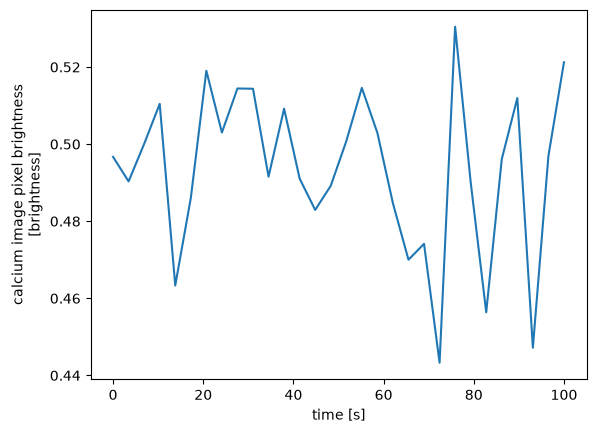

In [33]:
da.mean(dim=['x', 'y']).plot();

There are many, many more features that XArray provides to add convenience to an analysis, but this should be enough to get us started. 

**Example**: Wrap a 2-D NumPy array of EEG-like data in a `DataArray` with named dimensions, coordinates, and a name.

In [34]:
rng = np.random.default_rng(0)
time = np.linspace(0, 2, 1000)
channels = ['Fz', 'Cz', 'Pz', 'Oz']
values = rng.normal(size=(len(channels), len(time)))

eeg = xr.DataArray(
    data=values,
    dims=['channel', 'time'],
    coords={'channel': channels, 'time': time},
    name='eeg',
)
eeg

<xarray.DataArray 'eeg' (channel: 4, time: 1000)> Size: 32kB
array([[ 0.12573022, -0.13210486,  0.64042265, ...,  1.38997173,
        -0.66434209, -0.22997116],
       [ 1.18390191,  0.30382685,  0.19205435, ..., -2.01881162,
        -0.90942756,  0.36922933],
       [ 0.41925483, -0.50224455, -0.85769996, ..., -1.65759515,
        -1.99552682, -0.61334415],
       [-0.38847831, -0.27536744, -1.24011117, ...,  0.55029559,
         0.55104841, -0.8705243 ]], shape=(4, 1000))
Coordinates:
  * channel  (channel) <U2 32B 'Fz' 'Cz' 'Pz' 'Oz'
  * time     (time) float64 8kB 0.0 0.002002 0.004004 ... 1.996 1.998 2.0

**Exercise**: Get the `time` coordinate of the `eeg` DataArray.

In [35]:
eeg['time']

<xarray.DataArray 'time' (time: 1000)> Size: 8kB
array([0.      , 0.002002, 0.004004, ..., 1.995996, 1.997998, 2.      ],
      shape=(1000,))
Coordinates:
  * time     (time) float64 8kB 0.0 0.002002 0.004004 ... 1.996 1.998 2.0

**Exercise**: Select the channel labelled `'Cz'` using `.sel`.

In [36]:
eeg.sel(channel='Cz')

<xarray.DataArray 'eeg' (time: 1000)> Size: 8kB
array([ 1.18390191e+00,  3.03826845e-01,  1.92054350e-01,  2.65943448e-01,
       -1.36615788e+00, -3.89553474e-01, -9.56445654e-01,  1.97413652e-01,
       -5.43998130e-01, -4.40591215e-02, -7.72925633e-02, -3.63703849e-02,
       -3.47471219e-02, -6.52378106e-01, -1.05400280e+00, -6.64356309e-01,
        1.07153834e+00,  3.74161806e-01,  5.86955361e-01,  1.37996792e+00,
       -1.17943093e+00,  5.09952421e-01, -1.07507411e+00, -3.34332599e-01,
        4.84239843e-01,  1.61434527e+00, -7.82164942e-01, -9.47962536e-02,
        1.15623680e+00, -1.48980812e+00,  3.62112915e-01, -3.08278150e-01,
       -8.81694971e-01,  1.46630823e-01,  5.94925862e-01, -9.12099762e-01,
        3.79989782e-01,  1.73369990e-01, -1.24181331e+00,  1.55341287e+00,
        1.08990267e+00, -8.59926748e-01, -5.86630883e-01,  7.70780234e-01,
       -4.95449047e-01, -1.83971861e+00,  1.04888211e+00,  8.78142297e-03,
        1.90702619e+00,  3.57467123e-01,  1.90992489e-01,  2.87450048e+00,
       -1.71867346e-01, -9.51815765e-01,  2.29197980e-01,  1.13575490e+00,
       -1.16512014e+00, -9.08265109e-01,  4.49777098e-01, -3.19734539e+00,
       -1.09267866e+00,  7.95484082e-01, -5.86739916e-01, -1.62648313e+00,
        1.92556666e+00, -1.41053516e+00, -5.23365547e-01, -3.72731499e-01,
        8.31443940e-02, -3.69505202e-01, -8.09650786e-02,  5.74945791e-02,
       -8.66764288e-02,  9.32738407e-02, -2.37892569e+00,  4.41064698e-01,
       -1.40445670e+00, -2.16664551e+00,  1.38134791e+00, -1.28551528e+00,
...
       -2.04496213e-02, -3.17708018e-01, -1.40671992e+00,  1.43973441e+00,
        1.56344292e+00, -5.64182503e-01,  5.21928192e-01, -1.48806679e-01,
        2.43440708e-01,  1.53213096e+00, -2.68640614e-01,  1.79216748e+00,
       -2.88194853e-01, -9.35539343e-02,  1.88931744e+00,  2.75217197e-01,
       -2.03194163e+00,  2.24802875e-01, -1.28185323e+00, -1.66260289e+00,
       -9.42642864e-01,  3.26080381e-01, -1.11336765e+00, -1.40125851e+00,
       -3.79761532e-01,  4.04610648e-01, -6.96378284e-01, -1.30643639e+00,
       -2.17269261e+00, -7.76202488e-01,  8.44308442e-01,  1.00209022e+00,
        7.89811452e-01, -1.75291242e-01,  1.29351384e-01,  1.26770345e+00,
       -8.68677427e-01,  3.64075576e-01, -1.87089640e+00,  6.82297662e-01,
       -4.51043039e-01, -1.15563144e+00,  7.72833948e-01, -1.11123495e+00,
       -8.67281678e-01,  1.53681842e+00, -1.04602508e+00, -6.56005027e-01,
       -6.83254494e-01,  7.84800952e-01, -1.83591170e+00,  1.25039568e+00,
       -2.43353864e-01, -3.16866355e-01, -8.96681417e-01, -1.45451328e-01,
        1.47039352e+00,  2.12852386e-01, -9.32540192e-01, -3.47355163e-01,
        5.34453067e-01,  8.53250722e-02, -2.57310592e-01,  6.04572913e-01,
        3.61086685e-01, -1.07771601e+00, -1.91491635e+00,  5.00488203e-01,
        1.85744412e+00, -8.20731394e-01, -1.41011717e-01,  1.35408138e+00,
        1.73963397e+00,  6.52358877e-02,  1.24972527e+00,  7.50633971e-01,
       -5.55815730e-01, -2.01881162e+00, -9.09427562e-01,  3.69229331e-01])
Coordinates:
  * time     (time) float64 8kB 0.0 0.002002 0.004004 ... 1.996 1.998 2.0
    channel  <U2 8B 'Cz'

**Exercise**: Select the data between 0.5 and 1.0 seconds for channels `'Fz'` and `'Cz'`.

In [37]:
eeg.sel(time=slice(0.5, 1.0), channel=['Fz', 'Cz'])

<xarray.DataArray 'eeg' (channel: 2, time: 250)> Size: 4kB
array([[ 2.01910002e-01, -3.88350386e-02,  1.06632455e+00,
        -9.21633924e-01,  8.04716931e-01,  8.52748471e-01,
        -6.67687292e-01,  1.63244006e-01, -8.30751957e-01,
         2.34580807e+00, -7.04139562e-01, -4.53074444e-01,
        -1.06583802e+00, -3.46121275e-01, -5.87602670e-03,
         7.67789135e-01, -6.10486646e-01, -1.85773959e-01,
        -1.41648937e+00, -8.27402227e-01,  2.75580756e+00,
         1.04124319e+00, -7.81424042e-01, -1.33739724e+00,
        -9.75582831e-01, -2.16908595e-02,  3.47277884e-02,
        -7.44360601e-01, -1.28657447e+00,  1.42237851e+00,
         4.51685451e-01, -3.74568020e-01, -2.20661208e-01,
        -5.29530459e-01, -2.93604545e+00,  1.15661827e-01,
        -1.07054441e+00, -1.00268430e+00, -6.40262405e-01,
         7.32301715e-01, -1.17053081e+00, -1.43428146e+00,
         6.39852075e-01,  7.54368905e-01, -9.58933708e-01,
         5.62397677e-01, -2.91632430e-01,  3.01292177e-01,
        -1.26096028e+00,  8.32894449e-01,  1.20325895e+00,
         6.37073236e-01,  5.58339962e-01, -3.77227516e+00,
         2.60629749e-01, -2.54453167e-02, -1.47045507e-01,
        -6.30577990e-01,  5.53649749e-02,  4.12117405e-01,
...
        -9.28744286e-01, -1.12398084e+00, -6.40181104e-02,
         3.23613327e-01,  5.03171892e-01,  7.81969353e-01,
         9.79585129e-01, -2.40307670e+00,  9.03440333e-01,
        -1.04744778e+00,  1.11406857e+00,  3.36644328e-01,
         6.30559818e-01, -5.40925748e-01,  2.82651321e-01,
        -1.86721258e+00,  1.09524662e+00, -3.30838739e-01,
        -2.58908029e+00,  1.06148355e+00,  1.67677373e+00,
        -8.76129516e-01,  1.21270989e+00, -7.49755451e-01,
        -2.26652063e+00, -3.57892474e-01,  3.26136452e-01,
         1.33551129e-01,  1.03597949e-01,  2.96422858e-01,
         2.16555664e-01, -2.16038303e-01, -6.01381373e-01,
        -2.65800848e-01, -3.51672566e-01, -3.02922623e-01,
        -1.10295343e+00, -5.42594385e-01,  8.22261888e-02,
         3.09418910e-01, -6.40289475e-02, -1.83659914e-01,
         5.34449874e-01,  8.14468661e-01,  6.80079879e-01,
        -1.74990909e+00, -4.55405091e-01,  7.05654587e-01,
         5.15397324e-01,  6.79810601e-01,  3.14351508e-01,
        -8.53536802e-01,  1.22256453e+00, -1.35958887e+00,
         9.85757792e-01, -1.63751312e-02, -1.47265422e+00,
        -3.96158801e-01]])
Coordinates:
  * channel  (channel) <U2 16B 'Fz' 'Cz'
  * time     (time) float64 2kB 0.5005 0.5025 0.5045 ... 0.995 0.997 0.999

**Exercise**: Compute the mean across time for every channel using the dimension name (not the axis number).

In [38]:
eeg.mean(dim='time')

<xarray.DataArray 'eeg' (channel: 4)> Size: 32B
array([-0.04802828, -0.00802289, -0.04586215,  0.04150495])
Coordinates:
  * channel  (channel) <U2 32B 'Fz' 'Cz' 'Pz' 'Oz'

**Exercise**: Attach metadata so that `eeg` has `units = 'uV'` and `description = 'simulated EEG data'`, and the `time` coordinate has `units = 's'`. Then plot `eeg.sel(channel='Cz')` and check that the axis labels in the plot use the attached metadata.

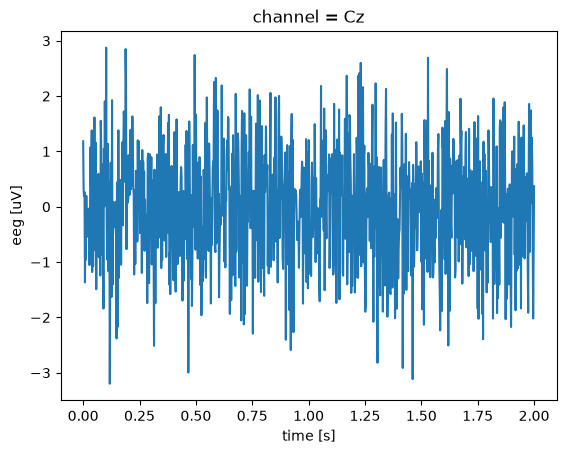

In [39]:
eeg.attrs = {'units': 'uV', 'description': 'simulated EEG data'}
eeg['time'].attrs = {'units': 's'}
eeg.sel(channel='Cz').plot();

## Saving and Loading DataArrays

### Background

Once data is organized in an Xarray structure, it can easily be saved to disk using scientific file formats such as NetCDF4, which is built on top of the HDF5 storage system. These formats are widely used in scientific computing because they support structured metadata, multidimensional datasets, and efficient storage of large arrays.

Saving data in these formats allows large datasets to be stored and accessed efficiently without requiring them to be fully loaded into memory. It also makes the data portable and accessible to tools outside of Python.

### Exercises

In this section you will save a `DataArray` to a NetCDF file and load it back into memory.

| Code | Description |
| :-- | :-- |
| `Path('data').mkdir(exist_ok=True)` | Create a directory if it does not already exist. |
| `da.to_netcdf('data/file.nc')` | Write a DataArray to a NetCDF file. |
| `xr.load_dataarray('data/file.nc')` | Read a DataArray back into memory from a file. |

**Exercise**: Run the cell below to create a DataArray assigned to a variable `da`. Then, use `da.to_netcdf()` with the `engine='netcdf4'` option to create an HDF5-compatible file called `example.nc`.

In [40]:
time = xr.DataArray(
    data = np.linspace(0, 100, 30),
    name = 'time',
    dims=['time'],
    attrs = {
        'units': 's',
        'description': 'time samples for each image frame'
    }
)

da = xr.DataArray(
    data=np.random.random(size=(10, 20, 30)),
    name='image',
    dims=['x', 'y', 'time'],
    coords = {
        'time': time,
    },
    attrs = {
        'units': 'brightness',
        'description': 'A generated random image stack',
        'long_name': 'calcium image pixel brightness',
    }
)
da

<xarray.DataArray 'image' (x: 10, y: 20, time: 30)> Size: 48kB
array([[[0.06952191, 0.49376032, 0.52997541, ..., 0.61186104,
         0.99919222, 0.95578138],
        [0.52511255, 0.62563855, 0.97272636, ..., 0.60918743,
         0.51307212, 0.08971958],
        [0.18953417, 0.35035024, 0.92980735, ..., 0.58078305,
         0.82312887, 0.04078894],
        ...,
        [0.6993418 , 0.7541728 , 0.03623807, ..., 0.26574345,
         0.38851009, 0.96894168],
        [0.1123437 , 0.60529093, 0.85669449, ..., 0.4093544 ,
         0.89235575, 0.87601579],
        [0.29850678, 0.19027845, 0.14026178, ..., 0.63887328,
         0.64077909, 0.17263317]],

       [[0.69299264, 0.3615762 , 0.96399611, ..., 0.81792469,
         0.55792063, 0.80493613],
        [0.45837387, 0.8310692 , 0.24987724, ..., 0.27723497,
         0.2411854 , 0.79643413],
        [0.68804958, 0.64042993, 0.64323487, ..., 0.06541218,
         0.12343932, 0.18268125],
...
        [0.73516567, 0.06632681, 0.33308418, ..., 0.956873  ,
         0.21216365, 0.0850527 ],
        [0.69468759, 0.51141442, 0.79066346, ..., 0.53195239,
         0.06893575, 0.82494204],
        [0.75101106, 0.74626961, 0.17943619, ..., 0.28059954,
         0.41452954, 0.4726452 ]],

       [[0.06089189, 0.59830979, 0.64551863, ..., 0.60316252,
         0.75184414, 0.81970458],
        [0.97369308, 0.15496696, 0.18237082, ..., 0.32760644,
         0.24518565, 0.93212902],
        [0.70861389, 0.84445225, 0.95828178, ..., 0.47671634,
         0.91525481, 0.3848047 ],
        ...,
        [0.37438911, 0.67460367, 0.02770893, ..., 0.38270012,
         0.19449329, 0.55836184],
        [0.20520098, 0.52298912, 0.21751451, ..., 0.00942342,
         0.75941651, 0.02450631],
        [0.25566699, 0.28107795, 0.72047107, ..., 0.15423546,
         0.74244853, 0.32983507]]], shape=(10, 20, 30))
Coordinates:
  * time     (time) float64 240B 0.0 3.448 6.897 10.34 ... 93.1 96.55 100.0
Dimensions without coordinates: x, y
Attributes:
    units:        brightness
    description:  A generated random image stack
    long_name:    calcium image pixel brightness

In [41]:
da.to_netcdf('example.nc', engine='netcdf4')

**Exercise**: Open the `example.nc` file in the HDF5 Viewer at https://myhdf5.hdfgroup.org/ to verify it is a valid HDF5 file, and use it to do the following tasks:
  1. View the `time` variable as a line plot.
  2. View the `time` values themselves in a matrix.
  3. View the Image data as a heatmap.
  4. Find the "description" attribute for the `image` variable (hint: check the `inspect` tab) 

**Exercise**: Create a `data` directory next to this notebook.

In [42]:
Path('data').mkdir(exist_ok=True, parents=True)

**Exercise**: Run the cell below to create the `eeg` DataArray. Then, save the `eeg` DataArray to `data/eeg.nc`.

In [43]:
rng = np.random.default_rng(0)
time = np.linspace(0, 2, 1000)
channels = ['Fz', 'Cz', 'Pz', 'Oz']
values = rng.normal(size=(len(channels), len(time)))

eeg = xr.DataArray(
    data=values,
    dims=['channel', 'time'],
    coords={'channel': channels, 'time': time},
    name='eeg',
)
eeg

<xarray.DataArray 'eeg' (channel: 4, time: 1000)> Size: 32kB
array([[ 0.12573022, -0.13210486,  0.64042265, ...,  1.38997173,
        -0.66434209, -0.22997116],
       [ 1.18390191,  0.30382685,  0.19205435, ..., -2.01881162,
        -0.90942756,  0.36922933],
       [ 0.41925483, -0.50224455, -0.85769996, ..., -1.65759515,
        -1.99552682, -0.61334415],
       [-0.38847831, -0.27536744, -1.24011117, ...,  0.55029559,
         0.55104841, -0.8705243 ]], shape=(4, 1000))
Coordinates:
  * channel  (channel) <U2 32B 'Fz' 'Cz' 'Pz' 'Oz'
  * time     (time) float64 8kB 0.0 0.002002 0.004004 ... 1.996 1.998 2.0

In [44]:
eeg.to_netcdf('data/eeg.nc')

**Exercise**: Load `data/eeg.nc` into a new variable and display it to verify that its dimensions, coordinates, and attributes match the original.

In [45]:
eeg_loaded = xr.load_dataarray('data/eeg.nc')
eeg_loaded

<xarray.DataArray 'eeg' (channel: 4, time: 1000)> Size: 32kB
array([[ 0.12573022, -0.13210486,  0.64042265, ...,  1.38997173,
        -0.66434209, -0.22997116],
       [ 1.18390191,  0.30382685,  0.19205435, ..., -2.01881162,
        -0.90942756,  0.36922933],
       [ 0.41925483, -0.50224455, -0.85769996, ..., -1.65759515,
        -1.99552682, -0.61334415],
       [-0.38847831, -0.27536744, -1.24011117, ...,  0.55029559,
         0.55104841, -0.8705243 ]], shape=(4, 1000))
Coordinates:
  * channel  (channel) <U2 32B 'Fz' 'Cz' 'Pz' 'Oz'
  * time     (time) float64 8kB 0.0 0.002002 0.004004 ... 1.996 1.998 2.0